# **Spotify Songs** | What Makes a Song Go Viral?

---

| Nama | NRP |
|---|---|
| Rahma Sakinah | 5025241222 |

Dataset :
https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs

Dataset ini berisi **28.356 lagu** dari Spotify dengan **23 fitur audio** seperti danceability, energy, valence, tempo, dan loudness. Tujuan utama adalah mengidentifikasi pola fitur audio yang membuat sebuah lagu menjadi populer.

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, silhouette_score)
from sklearn.decomposition import PCA

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
sns.set_style('whitegrid')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
df = pd.read_csv('spotify_songs.csv')

print("Dataset berhasil diload")
print(f"Shape: {df.shape}")
print(f"\nKolom ({len(df.columns)}):")
for col in df.columns:
    print(f"  - {col}")

df.head()

Dataset berhasil diload
Shape: (32833, 23)

Kolom (23):
  - track_id
  - track_name
  - track_artist
  - track_popularity
  - track_album_id
  - track_album_name
  - track_album_release_date
  - playlist_name
  - playlist_id
  - playlist_genre
  - playlist_subgenre
  - danceability
  - energy
  - key
  - loudness
  - mode
  - speechiness
  - acousticness
  - instrumentalness
  - liveness
  - valence
  - tempo
  - duration_ms


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


---
## **Eksplorasi Dataset (EDA)**
---

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

In [6]:
print(df.isnull().sum())

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64


In [7]:
df.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


### Hapus missing values
---

In [24]:
# Hapus baris yang missing values
df_clean = df.dropna()

print(f"Shape sebelum : {df.shape}")
print(f"Shape sesudah : {df_clean.shape}")
print(f"Total dihapus : {len(df) - len(df_clean)} baris")

Shape sebelum : (32833, 23)
Shape sesudah : (32828, 23)
Total dihapus : 5 baris


### Distribusi Fitur Audio
---

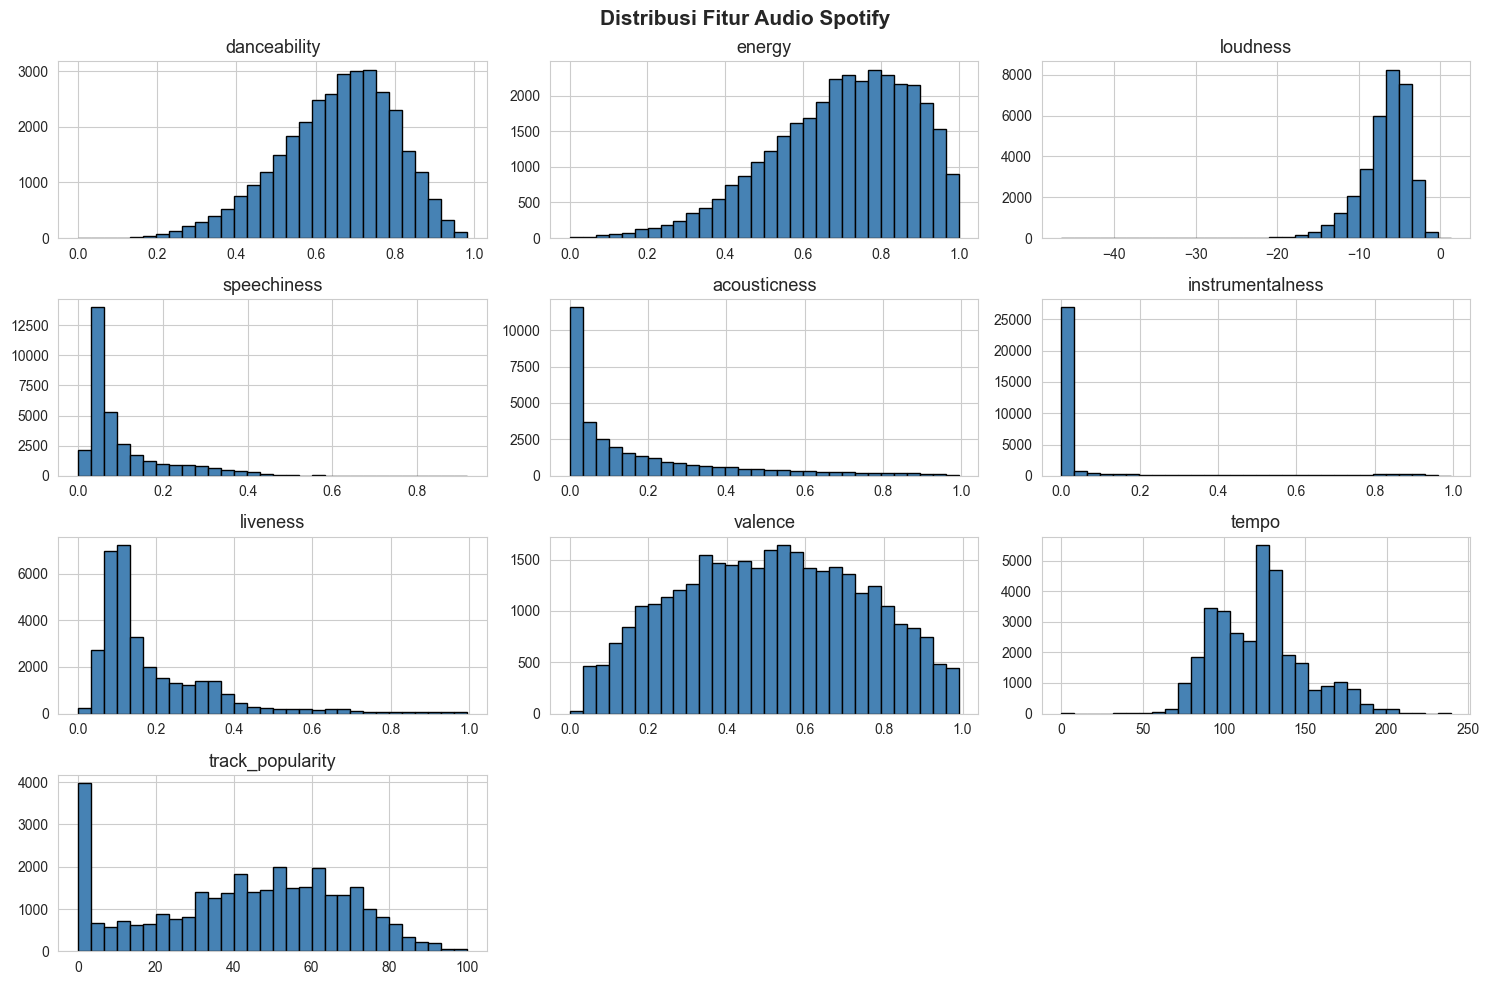

In [25]:
# Kolom numerik / fitur audio
audio_cols = ['danceability', 'energy', 'loudness', 'speechiness','acousticness', 'instrumentalness', 'liveness', 'valence','tempo', 'track_popularity']

# Histogram distribusi
df_clean[audio_cols].hist(bins=30, figsize=(15, 10), color='steelblue', edgecolor='black')
plt.suptitle('Distribusi Fitur Audio Spotify', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Korelasi Antar Fitur

---

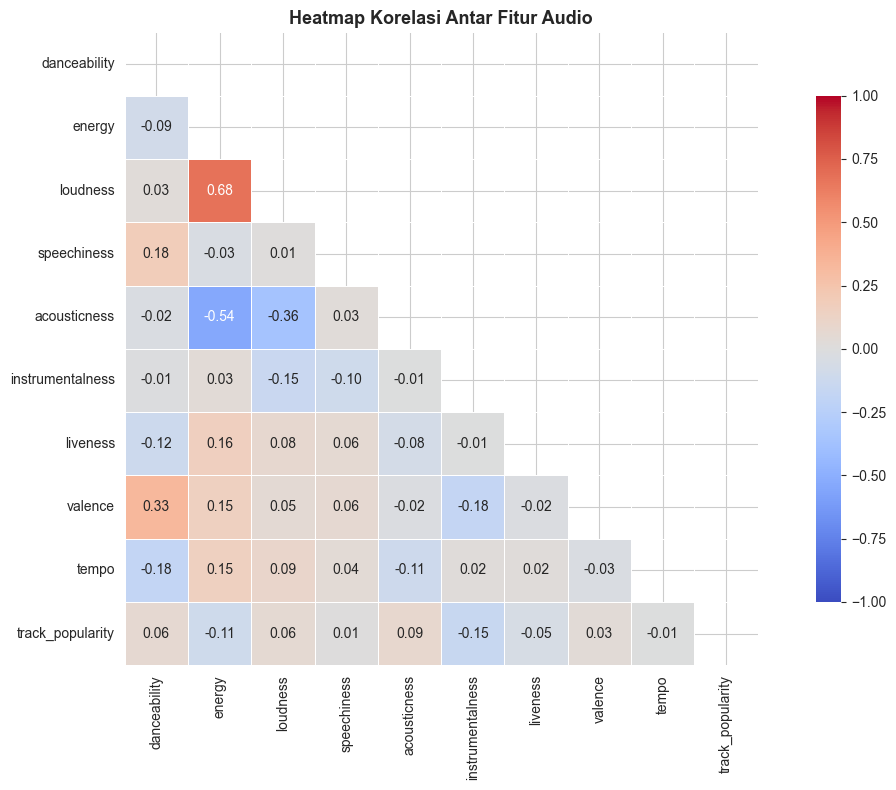

In [26]:
# Heatmap korelasi
plt.figure(figsize=(12, 8))
corr = df_clean[audio_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Heatmap Korelasi Antar Fitur Audio', fontweight='bold')
plt.tight_layout()
plt.show()

### Rata-rata popularitas per genre
---

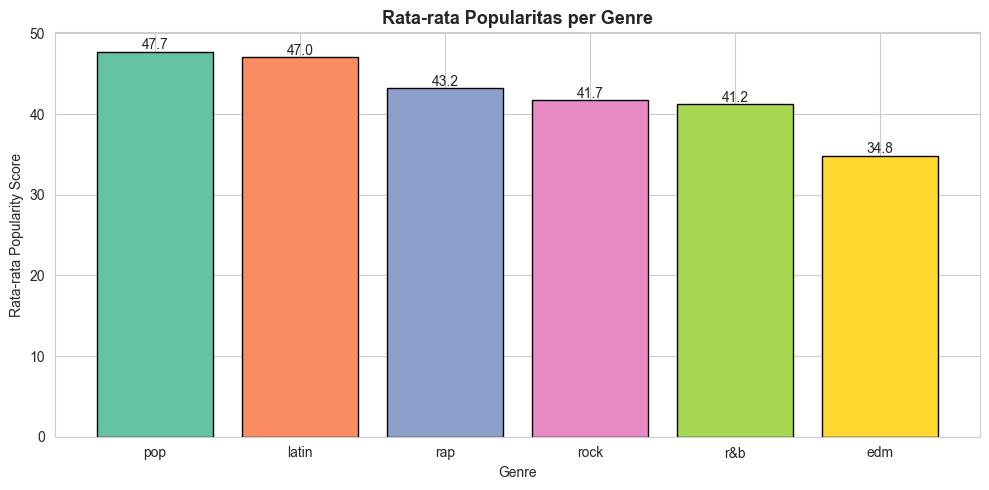

In [27]:
plt.figure(figsize=(10, 5))
genre_pop = df_clean.groupby('playlist_genre')['track_popularity'].mean().sort_values(ascending=False)
colors = sns.color_palette('Set2', len(genre_pop))
bars = plt.bar(genre_pop.index, genre_pop.values, color=colors, edgecolor='black')
plt.title('Rata-rata Popularitas per Genre', fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Rata-rata Popularity Score')
for bar, val in zip(bars, genre_pop.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}',
             ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Trend popularitas per tahun rilis
---

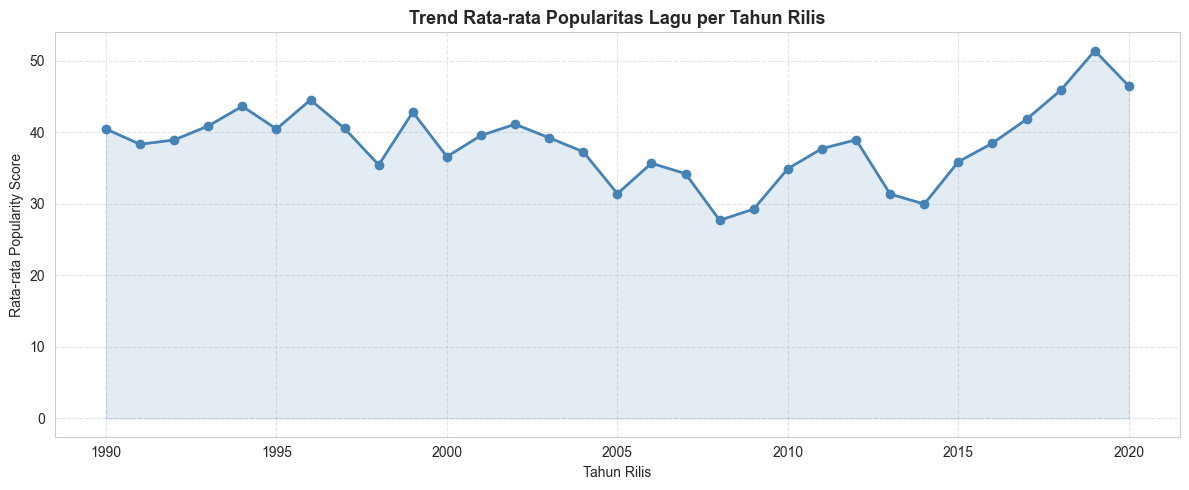

In [28]:
df_clean['release_year'] = pd.to_datetime(
    df_clean['track_album_release_date'], errors='coerce'
).dt.year

yearly_pop = df_clean.groupby('release_year')['track_popularity'].mean().dropna()
yearly_pop = yearly_pop[yearly_pop.index >= 1990]  # filter tahun masuk akal

plt.figure(figsize=(12, 5))
plt.plot(yearly_pop.index, yearly_pop.values, marker='o', color='steelblue', linewidth=2)
plt.fill_between(yearly_pop.index, yearly_pop.values, alpha=0.15, color='steelblue')
plt.title('Trend Rata-rata Popularitas Lagu per Tahun Rilis', fontweight='bold')
plt.xlabel('Tahun Rilis')
plt.ylabel('Rata-rata Popularity Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Boxplot popularitas per genre
---

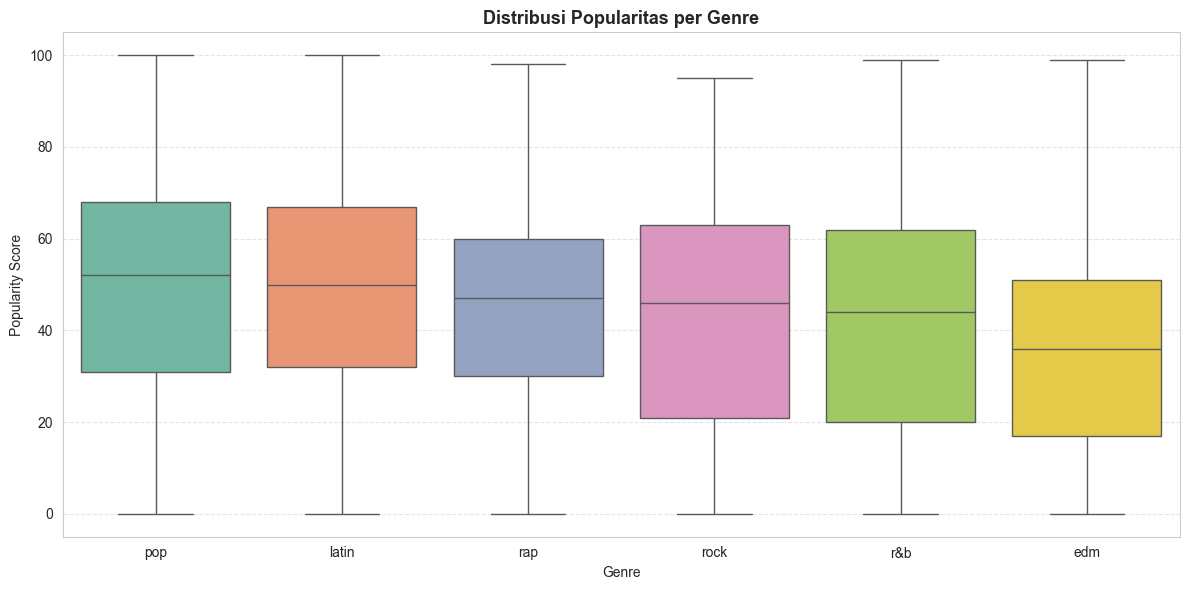

In [29]:
plt.figure(figsize=(12, 6))
order = df_clean.groupby('playlist_genre')['track_popularity'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='playlist_genre', y='track_popularity',
            order=order, palette='Set2')
plt.title('Distribusi Popularitas per Genre', fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Popularity Score')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

---
## **Feature Engineering**
---

### Labeling Popularitas
---

In [30]:
# Buat label kategori popularitas
def label_popularity(score):
    if score >= 70:
        return 'viral'
    elif score >= 45:
        return 'popular'
    elif score >= 20:
        return 'average'
    else:
        return 'obscure'

df_clean['popularity_label'] = df_clean['track_popularity'].apply(label_popularity)

print("Distribusi label:")
print(df_clean['popularity_label'].value_counts())

Distribusi label:
popularity_label
popular    12019
average     8760
obscure     7215
viral       4834
Name: count, dtype: int64


**Insight:**
- Mayoritas lagu masuk kategori `popular` dan `average`
- Hanya ~14.7% lagu yang masuk kategori `viral` (popularity ≥ 70)
- Distribusi ini mencerminkan kenyataan — tidak semua lagu bisa viral

### Kolom tambahan
---

In [31]:
df_clean['energy_dance_ratio'] = (df_clean['energy'] / (df_clean['danceability'] + 1e-6)).clip(upper=10)
df_clean['mood_score'] = (df_clean['valence'] + df_clean['danceability']) / 2
df_clean['duration_min'] = df_clean['duration_ms'] / 60000

print("kolom tambahan dibuat")
print(df_clean[['energy_dance_ratio', 'mood_score', 'duration_min']].describe())

kolom tambahan dibuat
       energy_dance_ratio    mood_score  duration_min
count        32828.000000  32828.000000  32828.000000
mean             1.144023      0.582703      3.763280
std              0.503804      0.156344      0.997275
min              0.002224      0.000000      0.066667
25%              0.827813      0.466000      3.130075
50%              1.070414      0.587000      3.600000
75%              1.355766      0.704500      4.226354
max             10.000000      0.964500      8.630167


### Prepare Modeling
---

In [49]:
from sklearn.preprocessing import LabelEncoder

# Encode playlist_genre
genre_encoder = LabelEncoder()
df_clean['genre_encoded'] = genre_encoder.fit_transform(df_clean['playlist_genre'])

print("Genre yang ada:", genre_encoder.classes_)

# Fitur yang dipakai untuk training (tambah genre_encoded)
feature_cols = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'energy_dance_ratio', 'mood_score', 'duration_min',
    'genre_encoded'
]

# Encode label target
le = LabelEncoder()
df_clean['popularity_encoded'] = le.fit_transform(df_clean['popularity_label'])

print("Urutan label:", le.classes_)

X = df_clean[feature_cols]
y = df_clean['popularity_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nData training : {X_train.shape}")
print(f"Data testing  : {X_test.shape}")

Genre yang ada: ['edm' 'latin' 'pop' 'r&b' 'rap' 'rock']
Urutan label: ['average' 'obscure' 'popular' 'viral']

Data training : (26262, 13)
Data testing  : (6566, 13)


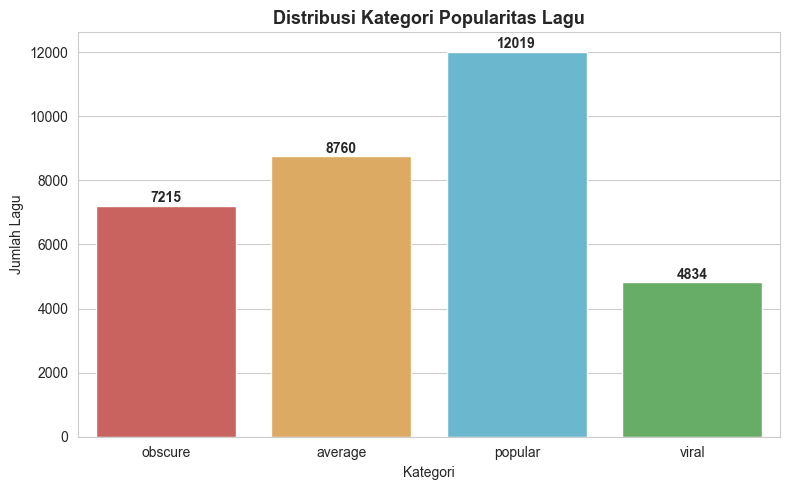

In [50]:
plt.figure(figsize=(8, 5))
order = ['obscure', 'average', 'popular', 'viral']
colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c']
sns.countplot(data=df_clean, x='popularity_label', order=order, palette=colors)
plt.title('Distribusi Kategori Popularitas Lagu', fontweight='bold')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Lagu')
for i, v in enumerate(df_clean['popularity_label'].value_counts()[order]):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

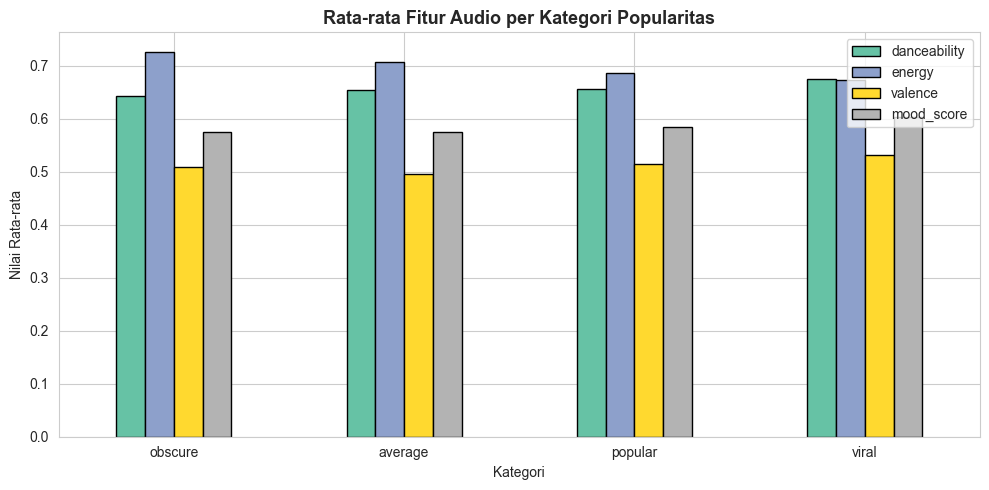

In [51]:
feature_means = df_clean.groupby('popularity_label')[
    ['danceability', 'energy', 'valence', 'mood_score']
].mean().reindex(order)

feature_means.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Rata-rata Fitur Audio per Kategori Popularitas', fontweight='bold')
plt.xlabel('Kategori')
plt.ylabel('Nilai Rata-rata')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
## **Modeling**
---

### Training & Evaluasi Model
---

In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': pipe, 'accuracy': acc, 'y_pred': y_pred}
    print(f"{name:25s}  Accuracy: {acc:.4f}")

Logistic Regression        Accuracy: 0.3940
Random Forest              Accuracy: 0.5117
XGBoost                    Accuracy: 0.4679


### Perbandingan Akurasi Model
---

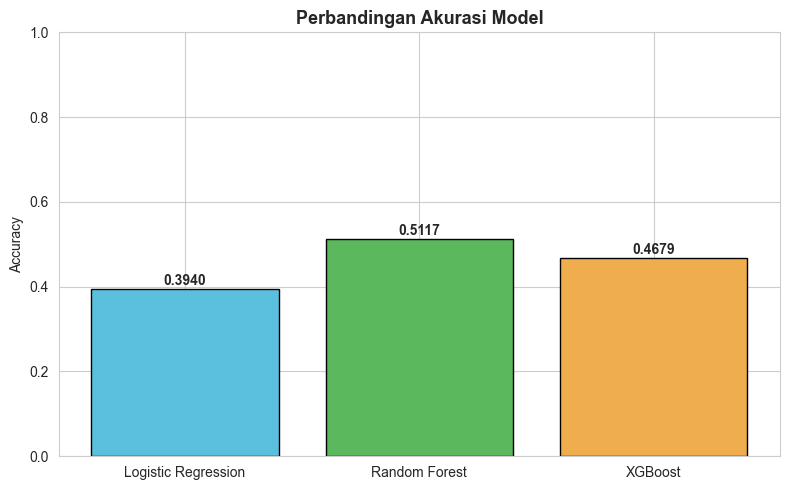

In [54]:
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=['#5bc0de', '#5cb85c', '#f0ad4e'], edgecolor='black')
plt.title('Perbandingan Akurasi Model', fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Classification Report Model Terbaik (Random Forest)
---

In [55]:
best_name = max(results, key=lambda x: results[x]['accuracy'])
best_pred = results[best_name]['y_pred']

print(f"Model terbaik: {best_name}\n")
print(classification_report(y_test, best_pred, target_names=le.classes_))

Model terbaik: Random Forest

              precision    recall  f1-score   support

     average       0.45      0.35      0.39      1752
     obscure       0.48      0.29      0.36      1443
     popular       0.48      0.72      0.58      2404
       viral       0.79      0.61      0.69       967

    accuracy                           0.51      6566
   macro avg       0.55      0.49      0.51      6566
weighted avg       0.52      0.51      0.50      6566



### Confusion Matrix
---

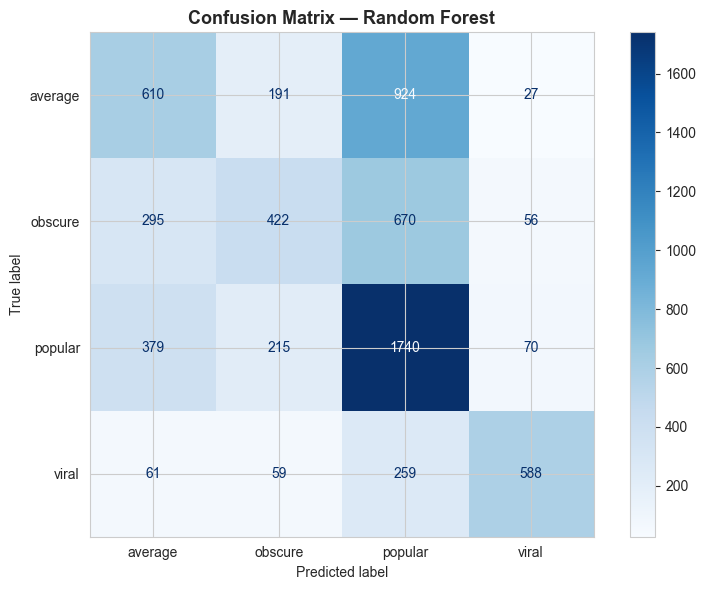

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Importance
---

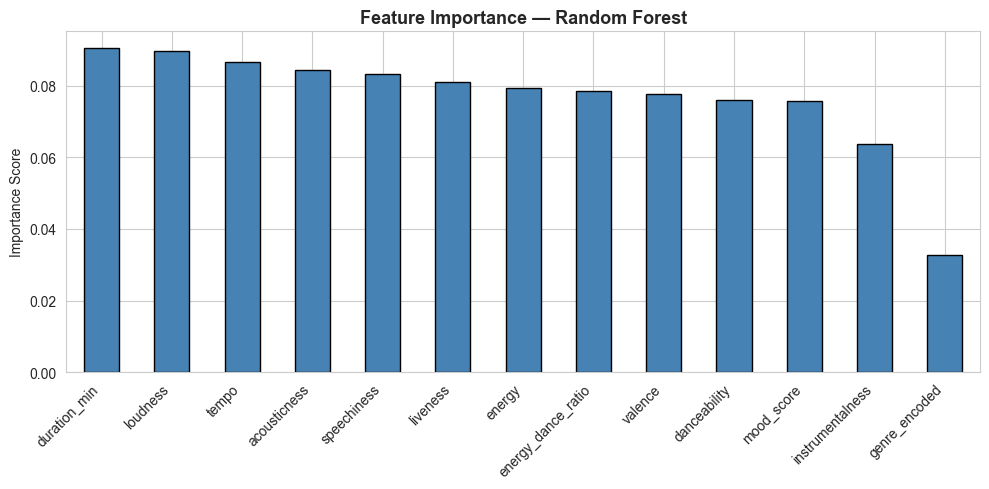

In [57]:
best_model = results['Random Forest']['model']
importances = best_model.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Cross Validation
---

In [58]:
print("Cross Validation Score (5-fold):\n")
for name, res in results.items():
    cv_scores = cross_val_score(res['model'], X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name:25s}  Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")

Cross Validation Score (5-fold):

Logistic Regression        Mean: 0.3922 | Std: 0.0025
Random Forest              Mean: 0.4955 | Std: 0.0091
XGBoost                    Mean: 0.4613 | Std: 0.0040


### Learning Curve
---

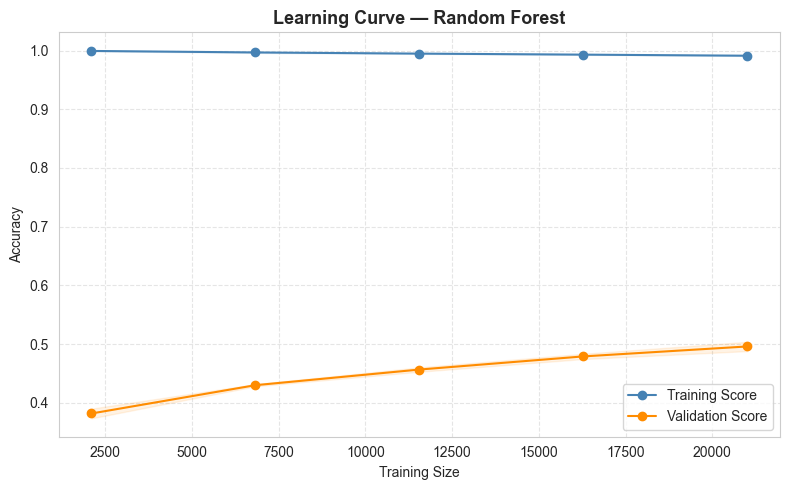

In [59]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    test_mean  = test_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    test_std   = test_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training Score')
    plt.plot(train_sizes, test_mean,  'o-', color='darkorange', label='Validation Score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='steelblue')
    plt.fill_between(train_sizes, test_mean  - test_std,  test_mean  + test_std,  alpha=0.1, color='darkorange')
    plt.title(f'Learning Curve — {title}', fontweight='bold')
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_learning_curve(results['Random Forest']['model'], 'Random Forest', X_train, y_train)

### Hyperparameter Tuning (Random Forest)
---

In [60]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'model__n_estimators'    : [50, 100, 200],
    'model__max_depth'       : [5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

search = RandomizedSearchCV(
    pipe_rf, param_dist,
    n_iter=20, cv=5,
    scoring='accuracy',
    random_state=42, n_jobs=-1
)

search.fit(X_train, y_train)

print(f"Best params : {search.best_params_}")
print(f"Best CV score: {search.best_score_:.4f}")

y_pred_tuned = search.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Test accuracy setelah tuning: {acc_tuned:.4f}")

Best params : {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': None}
Best CV score: 0.4978
Test accuracy setelah tuning: 0.5148


### Learning Curve Setelah Tuning
---

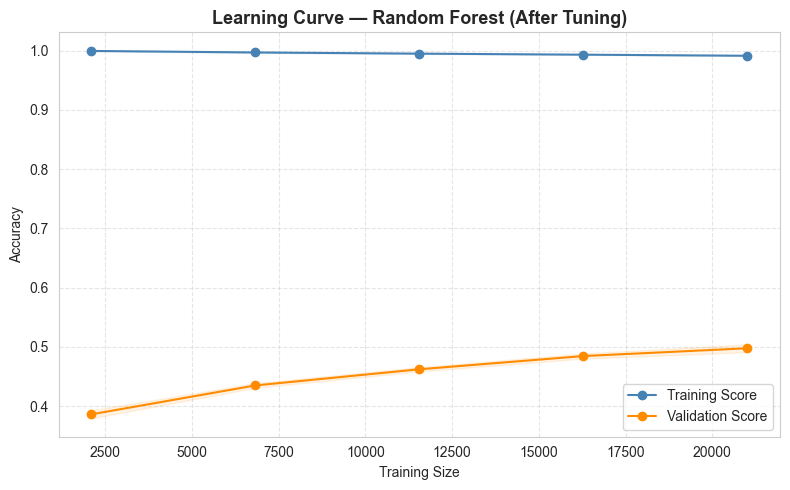

In [61]:
plot_learning_curve(search.best_estimator_, 'Random Forest (After Tuning)', X_train, y_train)

---
## **Kesimpulan**
---

### Performa Model
---

| Model | Accuracy |
|---|---|
| Logistic Regression | 39.40% |
| XGBoost | 46.79% |
| Random Forest | **51.17%** |

Dari ketiga model yang dicoba, **Random Forest** jadi yang paling baik
dengan akurasi **51.17%** di data testing

### Analisis Classification Report
---
Model justru paling bagus mengenali lagu **viral** (precision 0.79), yang artinya kalau model bilang sebuah lagu viral, kemungkinan besar memang benar. Tapi model masih kesulitan membedakan lagu **average** dengan **obscure**, bisa jadi karena secara audio keduanya memang mirip-mirip.

### Kenapa Akurasi Segini?
---
menurut saya, 51% itu tidak tinggi atau bisa dikatakan jelek. Tapi setelah ditelusuri, masalahnya ada di data yang dipilih dan topik yang di lanjutkan

Popularitas lagu di dunia nyata itu ternyata lebih kompleks. Fitur audio seperti danceability atau tempo itu cuma ngegambarin "seperti apa bunyinya", bukan "seberapa besar kemungkinan orang dengerin." Yang nentuin lagu bisa viral atau tidak itu justru hal-hal yang tidak ada di 
dataset ini:
- Seberapa besar nama artistnya
- Seberapa gencar promosinya
- Lagi viral di TikTok atau tidak
- Timing rilisnya pas atau tidak

### Yang Saya Temukan dari Data
- `energy` & `loudness` korelasi **0.68**, lagu yang energik memang cenderung keras
- `energy` & `acousticness` korelasi **-0.54**, lagu akustik biasanya lebih kalem
- Lagu kategori `viral` rata-rata punya **danceability dan mood_score paling tinggi** dibanding kategori lain
- Tapi korelasi `track_popularity` sama semua fitur audio sangat rendah, di bawah 0.15 semua ini yang menjadi konfirmasi bahwa audio saja tidak cukup untuk memprediksi popularitas

sehingga prediksi saya modelnya mungkin saja dapat lebih akurat, jika ditambahkan dengan data data seperti:
- Jumlah followers artisnya
- Berapa banyak playlist yang nge-include lagu tersebut
- Data engagement di media sosial